## NOTEBOOK- Análise Exploratória do Dataset de Inadimplência

### Importação das bibliotecas



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

### Carregamento de dataset

In [2]:
dataset = fetch_ucirepo(id=350)

# Features
X = dataset.data.features

# Target
y = dataset.data.targets

print("Features:")
display(X.head())
print("\nTarget:")
display(y.head())

Features:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679



Target:


,Y
0,1
1,1
2,0
3,0
4,0


### dimensão dados 

In [3]:
print("Dimensão das features:", X.shape)
print("Dimensão do target:", y.shape)

Dimensão das features: (30000, 23)
Dimensão do target: (30000, 1)


### identificação das colunas e tipos

In [4]:
print("Colunas das features:")
print(X.columns.tolist())
display(dataset.variables)

print("Tipos das features:")
print(X.dtypes)

print("\nTipo do target:")
print(y.dtypes)

Colunas das features:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,NaN,NaN,None,no
1,X1,Feature,Integer,NaN,LIMIT_BAL,None,no
2,X2,Feature,Integer,Sex,SEX,None,no
3,X3,Feature,Integer,Education Level,EDUCATION,None,no
4,X4,Feature,Integer,Marital Status,MARRIAGE,None,no
5,X5,Feature,Integer,Age,AGE,None,no
6,X6,Feature,Integer,NaN,PAY_0,None,no
7,X7,Feature,Integer,NaN,PAY_2,None,no
8,X8,Feature,Integer,NaN,PAY_3,None,no
9,X9,Feature,Integer,NaN,PAY_4,None,no


Tipos das features:
X1     int64
X2     int64
X3     int64
X4     int64
X5     int64
X6     int64
X7     int64
X8     int64
X9     int64
X10    int64
X11    int64
X12    int64
X13    int64
X14    int64
X15    int64
X16    int64
X17    int64
X18    int64
X19    int64
X20    int64
X21    int64
X22    int64
X23    int64
dtype: object

Tipo do target:
Y    int64
dtype: object


### informação geral

In [5]:
X.info()

y.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
dtypes: int64(23)
memory us

### valores ausentes

In [6]:
print("Valores ausentes por coluna:")
display(X.isnull().sum())
print("Total de valores ausentes:", X.isnull().sum().sum())
print("Valores ausentes no target:", y.isnull().sum().sum())

Valores ausentes por coluna:


X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
dtype: int64

Total de valores ausentes: 0
Valores ausentes no target: 0


### registros duplicados

In [7]:
print("Duplicatas em X:", X.duplicated().sum())

dados = X.copy()
dados["Y"] = y.iloc[:, 0]
print("Duplicatas completas:", dados.duplicated().sum())

Duplicatas em X: 56
Duplicatas completas: 35


### duplicações nas features

In [8]:
duplicados_X = dados[
    dados.duplicated(subset=X.columns, keep=False)
]

print(
    "Registros envolvidos em duplicações de X:",
    len(duplicados_X)
)

display(
    duplicados_X
    .sort_values(by=X.columns.tolist())
    .head(20)
)

Registros envolvidos em duplicações de X: 108


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
12430,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
12432,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,0
14294,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
1759,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
10250,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7170,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
17032,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
291,50000,2,2,2,22,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
8297,50000,2,2,2,22,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
1983,80000,1,1,2,37,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1


### X iguais, mas Y diferentes

In [9]:
grupos = (
    dados
    .groupby(X.columns.tolist())["Y"]
    .nunique()
)

print(
    "Grupos de X idênticos com Y diferente:",
    (grupos > 1).sum()
)

Grupos de X idênticos com Y diferente: 21


### estatisticas descritivas

In [10]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


### variáveis categóricas

In [11]:
#X2 → sexo
#X3 → educação
#X4 → estado civil

for coluna in ["X2", "X3", "X4"]:
    print(f"\n{coluna}")
    display(
        X[coluna]
        .value_counts()
        .sort_index()
    )


X2


X2
1    11888
2    18112
Name: count, dtype: int64


X3


X3
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


X4


X4
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

### histórico de pagamento

In [12]:
colunas_pagamento = [
    "X6",
    "X7",
    "X8",
    "X9",
    "X10",
    "X11"
]

for coluna in colunas_pagamento:
    print(f"\n{coluna}")
    display(
        X[coluna]
        .value_counts()
        .sort_index()
    )


X6


X6
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


X7


X7
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64


X8


...

X9
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64


X10


X10
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64


X11


X11
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

### Variáveis financeiras


In [13]:
colunas_faturas = [
    "X12",
    "X13",
    "X14",
    "X15",
    "X16",
    "X17"
]

colunas_pagamentos = [
    "X18",
    "X19",
    "X20",
    "X21",
    "X22",
    "X23"
]

display(X[colunas_faturas].describe().T)
display(X[colunas_pagamentos].describe().T)

,count,mean,std,min,25%,50%,75%,max
X12,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
X13,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
X14,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
X15,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
X16,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
X17,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


,count,mean,std,min,25%,50%,75%,max
X18,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
X19,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
X20,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
X21,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
X22,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
X23,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


### valores negativos nas faturas

In [14]:
for coluna in colunas_faturas:
    negativos = (X[coluna] < 0).sum()

    print(
        f"{coluna}: {negativos} valores negativos"
    )


for coluna in colunas_faturas:

    negativos = X.loc[
        X[coluna] < 0,
        coluna
    ]

    print(
        f"\n{coluna}"
    )

    print(
        f"Quantidade: {len(negativos)}"
    )

    print(
        f"Mínimo: {negativos.min()}"
    )

    print(
        f"Mediana: {negativos.median()}"
    )

    print(
        f"Máximo: {negativos.max()}"
    )

X12: 590 valores negativos
X13: 669 valores negativos
X14: 655 valores negativos
X15: 675 valores negativos
X16: 655 valores negativos
X17: 688 valores negativos

X12
Quantidade: 590
Mínimo: -165580
Mediana: -90.5
Máximo: -1

X13
Quantidade: 669
Mínimo: -69777
Mediana: -123.0
Máximo: -1

X14
Quantidade: 655
Mínimo: -157264
Mediana: -150.0
Máximo: -1

X15
Quantidade: 675
Mínimo: -170000
Mediana: -155.0
Máximo: -1

X16
Quantidade: 655
Mínimo: -81334
Mediana: -200.0
Máximo: -1

X17
Quantidade: 688
Mínimo: -339603
Mediana: -202.5
Máximo: -1


### clientes com fatura negativa

In [15]:
tem_negativo = (
    X[colunas_faturas] < 0
).any(axis=1)

print(
    "Clientes com pelo menos uma fatura negativa:",
    tem_negativo.sum()
)

print(
    "Percentual:",
    tem_negativo.mean() * 100
)


quantidade_negativos = (
    X[colunas_faturas] < 0
).sum(axis=1)

display(
    quantidade_negativos
    .value_counts()
    .sort_index()
)

Clientes com pelo menos uma fatura negativa: 1930
Percentual: 6.433333333333334


0    28070
1      993
2      412
3      240
4      118
5       79
6       88
Name: count, dtype: int64

### valores extremos em faturas

In [16]:
for coluna in colunas_faturas:

    print(f"\n{coluna} - menores valores:")

    display(
        X[coluna]
        .nsmallest(10)
    )
    print(f"\n{coluna} - maiores valores:")
    display(
            X[coluna]
            .nlargest(10)
        )




X12 - menores valores:


12330   -165580
23003   -154973
8835     -15308
351      -14386
29779    -11545
27465    -10682
4635      -9802
4439      -9095
17204     -8187
3105      -7438
Name: X12, dtype: int64


X12 - maiores valores:


2197     964511
27557    746814
26547    653062
6912     630458
28142    626648
11557    621749
27498    613860
14553    610723
26227    608594
10780    604019
Name: X12, dtype: int64


X13 - menores valores:


...

2197     927171
20892    823540
28405    587067
8229     551702
13782    547880
23377    530672
21381    524315
25146    516139
24686    514114
27440    508213
Name: X16, dtype: int64


X17 - menores valores:


290     -339603
26097   -209051
12828   -150953
29491    -94625
28919    -73895
27080    -57060
12388    -51443
3525     -51183
21235    -46627
5548     -45734
Name: X17, dtype: int64


X17 - maiores valores:


2197     961664
1508     699944
8229     568638
1992     527711
5035     527566
25146    514975
10960    513798
5333     511905
20892    501370
24686    499100
Name: X17, dtype: int64

### Variável alvo

In [17]:
print("Distribuição do target:")

display(
    y.value_counts()
)

print("Proporção do target:")

display(
    y.value_counts(normalize=True) * 100
)

Distribuição do target:


Y
0    23364
1     6636
Name: count, dtype: int64

Proporção do target:


Y
0    77.88
1    22.12
Name: proportion, dtype: float64

### visualização das variáveis

#### Variável alvo

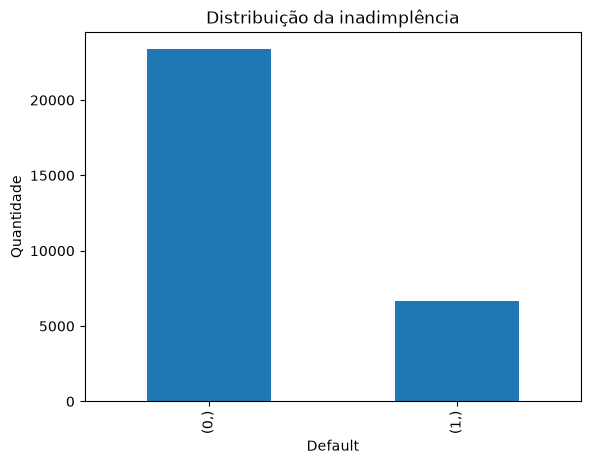

In [18]:
y.value_counts().plot(
    kind="bar"
)

plt.title("Distribuição da inadimplência")
plt.xlabel("Default")
plt.ylabel("Quantidade")

plt.show()

#### variáveis numéricas

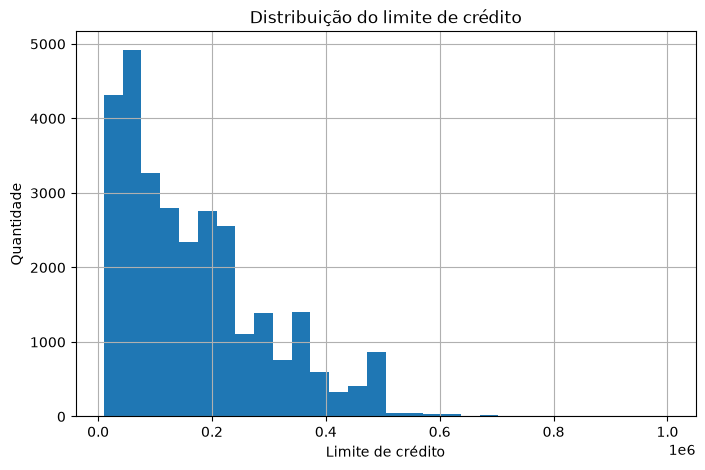

In [19]:
plt.figure(figsize=(8, 5))

X["X1"].hist(bins=30)

plt.title("Distribuição do limite de crédito")
plt.xlabel("Limite de crédito")
plt.ylabel("Quantidade")

plt.show()

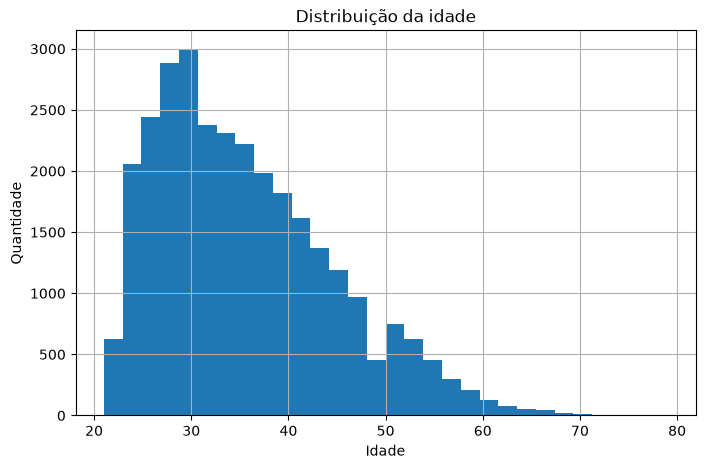

In [20]:
plt.figure(figsize=(8, 5))

X["X5"].hist(bins=30)

plt.title("Distribuição da idade")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

#### Variáveis financeiras

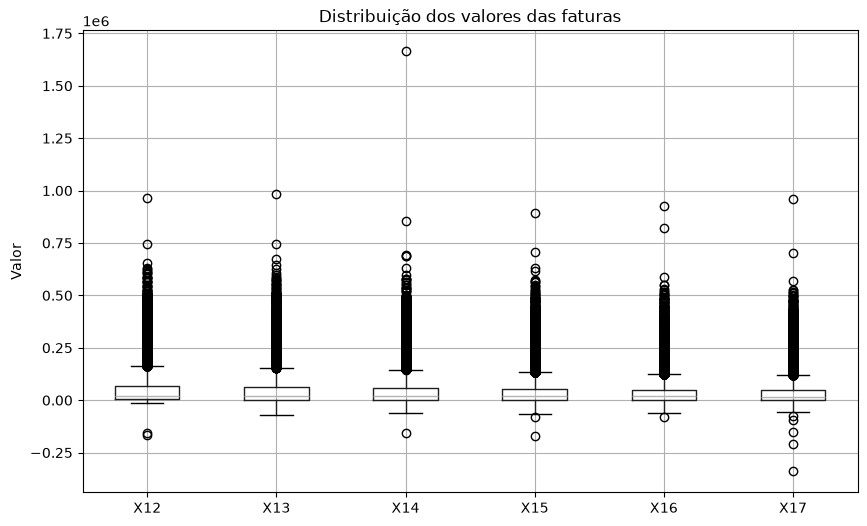

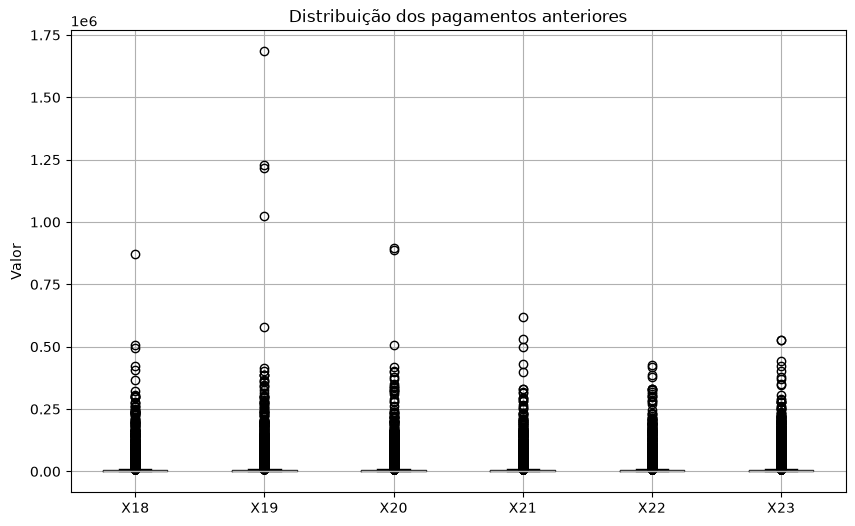

In [21]:
plt.figure(figsize=(10, 6))

X[colunas_faturas].boxplot()

plt.title("Distribuição dos valores das faturas")
plt.ylabel("Valor")

plt.show()


plt.figure(figsize=(10, 6))

X[colunas_pagamentos].boxplot()

plt.title("Distribuição dos pagamentos anteriores")
plt.ylabel("Valor")

plt.show()

### Correlção

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
X1,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,...,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595
X2,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,-0.055064,...,-0.024563,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766
X3,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,0.097520,...,0.013002,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200
X4,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,0.035629,...,-0.024909,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641
X5,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,-0.053826,...,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478
X6,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,0.509426,...,0.179785,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673
X7,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,0.622780,...,0.224146,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500
X8,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,0.686775,...,0.227494,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861
X9,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,0.819835,...,0.244983,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565
X10,-0.249411,-0.055064,0.097520,0.035629,-0.053826,0.509426,0.622780,0.686775,0.819835,1.000000,...,0.243335,0.271915,0.269783,0.262509,-0.006089,-0.003191,0.009062,-0.058299,-0.033337,-0.023027


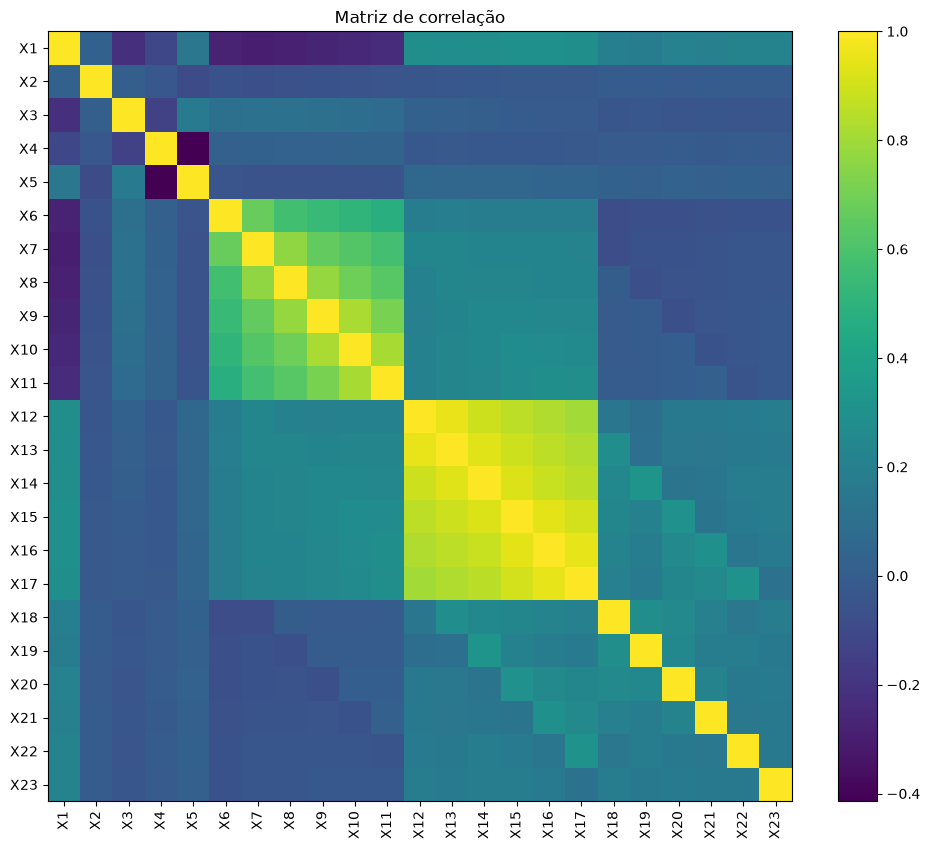

In [22]:
correlacao = X.corr()

display(correlacao)

plt.figure(figsize=(12, 10))

plt.imshow(
    correlacao,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacao.columns)),
    correlacao.columns
)

plt.title("Matriz de correlação")

plt.show()

##  Análise Exploratória de Dados (EDA) — Previsão de Inadimplência

---

### Conclusão da Análise Exploratória

A análise exploratória permitiu compreender a estrutura, a qualidade e as principais características do conjunto de dados utilizado para a previsão de inadimplência. O dataset possui **30.000 registros** e **23 variáveis preditoras**, além da **variável alvo Y**, que representa o pagamento ou inadimplência no mês seguinte. Não foram identificados valores ausentes nas variáveis analisadas.

####  Qualidade e Integridade dos Dados

* **Registros Duplicados:** Durante a análise, foram identificados **56 registros** com características duplicadas:
  * **35 registros completamente duplicados** (considerando inclusive a variável alvo $Y$). Estes serão removidos na etapa de preparação dos dados.
  * **21 grupos de registros** que possuem exatamente as mesmas características de entrada ($X$), porém com valores opostos para a variável alvo ($Y$). Como não é possível afirmar que representam erros, esses casos serão mantidos no dataset.
* **Variáveis Categóricas ($X3$ e $X4$):** Nas variáveis $X3$ (educação) e $X4$ (estado civil), foram encontrados códigos que não são explicados pela documentação consultada. Como não é seguro determinar seus significados individuais, esses códigos serão agrupados na categoria referente a "outros", evitando interpretações arbitrárias.

####  Variáveis Financeiras e Histórico de Pagamentos

* **Histórico de Pagamentos ($X6$ a $X11$):** Apresentam valores no intervalo entre $-2$ e $8$. Por aparecerem com frequência significativa e fazerem parte da estrutura original do conjunto de dados, serão preservados no primeiro experimento de modelagem, sem conversão para valores ausentes.
* **Valores de Fatura ($X12$ a $X17$):** Foram identificados valores negativos sem explicação prévia na documentação oficial. Decidiu-se mantê-los no primeiro modelo para posteriormente avaliar seu real impacto no desempenho do algoritmo.
* **Escala e Valores Extremos:** A análise das estatísticas descritivas apontou grande diferença de escala e a presença de valores extremos (*outliers*) nas variáveis financeiras, especialmente nos valores das faturas e pagamentos anteriores. Essa característica será diretamente tratada nas etapas de pré-processamento e seleção dos algoritmos.

---

####  Resumo da Análise

Com base nos resultados da EDA, o conjunto de dados apresenta condições adequadas para avançar para a etapa de pré-processamento e construção dos modelos de Machine Learning. As decisões tomadas durante essa etapa serão mantidas de forma explícita para que os resultados dos modelos possam ser reproduzidos e avaliados posteriormente.

---

###  Decisões para o Pré-processamento

| Problema encontrado | Decisão |
| :--- | :--- |
| **Valores ausentes** | Nenhum tratamento necessário |
| **35 duplicatas completas** | Remover |
| **21 grupos com X igual e Y diferente** | Manter |
| **X3 com códigos não documentados** | Agrupar como "Outros" |
| **X4 com código não documentado** | Agrupar como "Outros" |
| **X6–X11 com códigos -2 a 8** | Preservar inicialmente |
| **Valores negativos em X12–X17** | Preservar inicialmente |
| **Escalas diferentes** | Tratar no pré-processamento |
| **Valores extremos** | Investigar, sem remoção automática |

